# Day 14: Disease Classification using K-Nearest Neighbors (KNN)

**Dataset:** `disease_symptoms.csv`

In this notebook, we will:
1. Understand how the KNN algorithm works
2. Load and explore the Disease Symptoms dataset
3. Preprocess data with feature scaling (and understand why it matters for KNN)
4. Build a KNN classifier for **multiclass classification** (3 diseases: Flu, Common Cold, Allergy)
5. Evaluate the model using a multiclass confusion matrix and classification metrics
6. Find the optimal value of K
7. Visualize decision boundaries

## 1. Import Required Libraries

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report)

import warnings
warnings.filterwarnings('ignore')

## 2. What is K-Nearest Neighbors (KNN)?

KNN is one of the simplest machine learning algorithms. It works on a very intuitive idea:

> **"Tell me who your neighbors are, and I'll tell you who you are."**

### How it works:
1. Choose a value for **K** (number of neighbors to consider)
2. For a new data point, calculate the **distance** to all training points
3. Pick the **K closest** training points (nearest neighbors)
4. The new point gets the class that the **majority of its K neighbors** belong to (majority voting)

### Key characteristics:
- **No training phase**: KNN simply memorizes the training data
- **Distance-based**: features must be on similar scales (feature scaling is essential!)
- Makes no assumptions about the shape of the data
- Works for both **binary** (2 classes) and **multiclass** (3+ classes) classification

### 2.1 Distance Metric: Euclidean Distance

KNN measures "closeness" between points using a distance formula. The most common is **Euclidean Distance**:

$$d(p, q) = \sqrt{(p_1 - q_1)^2 + (p_2 - q_2)^2 + \dots + (p_n - q_n)^2}$$

For example, if we have two patients with features `[temperature, age]`:
- Patient A: [39.4, 26]
- Patient B: [36.6, 60]

$$d(A, B) = \sqrt{(39.4 - 36.6)^2 + (26 - 60)^2} = \sqrt{7.84 + 1156} \approx 34.1$$

**Problem:** Age (range 10-60) dominates the distance, while temperature (range 36-40) barely matters. This is why **feature scaling** is critical for KNN!

## 3. Load the Disease Symptoms Dataset

The Disease Symptoms dataset contains measurements of patients with symptoms like temperature, cough severity, fatigue level, headache intensity, body pain, sneezing frequency, and age. Each patient is diagnosed with one of 3 diseases: **Flu**, **Common Cold**, or **Allergy**.

In [18]:
df = pd.read_csv('disease_symptoms.csv')
print("Shape of dataset:", df.shape)
df.head()

Shape of dataset: (120, 8)


,temperature,cough_severity,fatigue_level,headache_intensity,body_pain,sneezing_frequency,age,disease
0,39.4,5,7,8,5,2,26,Flu
1,38.1,4,5,8,7,1,38,Flu
2,37.4,3,1,1,2,6,46,Common Cold
3,39.4,6,6,8,8,1,13,Flu
4,37.0,2,2,3,1,7,29,Common Cold


In [19]:
print("Dataset Info:")
print(df.info())

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   temperature         120 non-null    float64
 1   cough_severity      120 non-null    int64  
 2   fatigue_level       120 non-null    int64  
 3   headache_intensity  120 non-null    int64  
 4   body_pain           120 non-null    int64  
 5   sneezing_frequency  120 non-null    int64  
 6   age                 120 non-null    int64  
 7   disease             120 non-null    object 
dtypes: float64(1), int64(6), object(1)
memory usage: 7.6+ KB
None


In [20]:
print("\nStatistical Summary:")
df.describe()


Statistical Summary:


,temperature,cough_severity,fatigue_level,headache_intensity,body_pain,sneezing_frequency,age
count,120.000000,120.000000,120.000000,120.000000,120.000000,120.000000,120.000000
mean,37.752500,3.091667,3.450000,3.116667,2.533333,5.608333,37.625000
std,0.999072,2.188572,2.332993,2.619203,2.840089,2.867657,15.928972
min,36.200000,0.000000,1.000000,0.000000,0.000000,1.000000,10.000000
25%,37.000000,2.000000,2.000000,1.000000,0.000000,3.000000,25.000000
50%,37.400000,3.000000,2.000000,2.000000,1.000000,7.000000,38.000000
75%,38.425000,5.000000,6.000000,6.000000,5.000000,8.000000,50.250000
max,40.100000,7.000000,8.000000,8.000000,8.000000,9.000000,64.000000


In [21]:
print("Class Distribution:")
print(df['disease'].value_counts())
print(f"\nTotal samples: {len(df)}")

Class Distribution:
disease
Flu            40
Common Cold    40
Allergy        40
Name: count, dtype: int64

Total samples: 120


## 3.1 Handle Missing Values

In [22]:
print("Missing Values per Column:")
print(df.isnull().sum())
print(f"\nTotal Missing Values: {df.isnull().sum().sum()}")

Missing Values per Column:
temperature           0
cough_severity        0
fatigue_level         0
headache_intensity    0
body_pain             0
sneezing_frequency    0
age                   0
disease               0
dtype: int64

Total Missing Values: 0


In [23]:
print(f"Shape before dropping missing values: {df.shape}")
df = df.dropna()
print(f"Shape after dropping missing values: {df.shape}")

Shape before dropping missing values: (120, 8)
Shape after dropping missing values: (120, 8)


## 4. Exploratory Data Analysis (EDA)

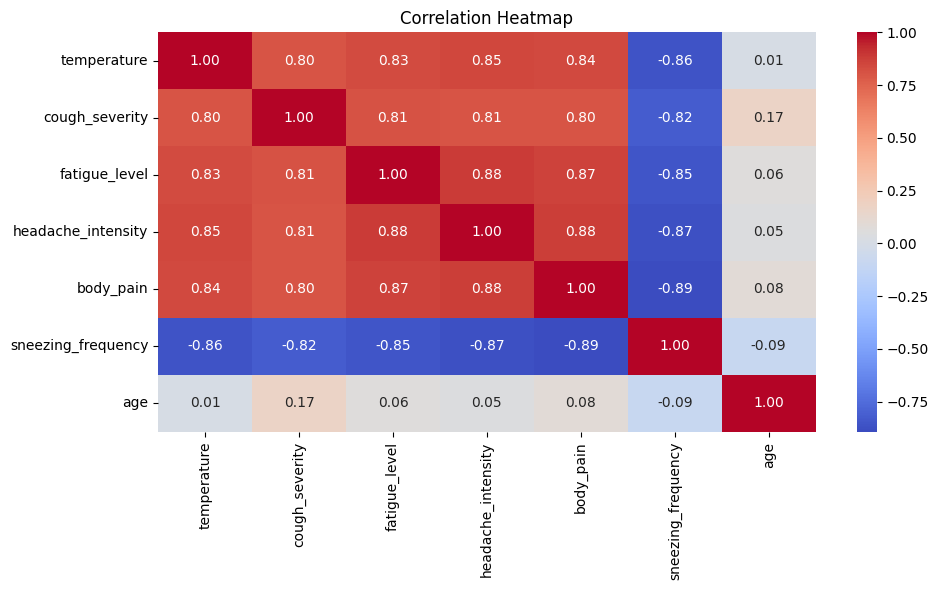

In [24]:
# Correlation Heatmap
numerical_cols = ['temperature', 'cough_severity', 'fatigue_level', 'headache_intensity',
                  'body_pain', 'sneezing_frequency', 'age']
plt.figure(figsize=(10, 6))
sns.heatmap(df[numerical_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

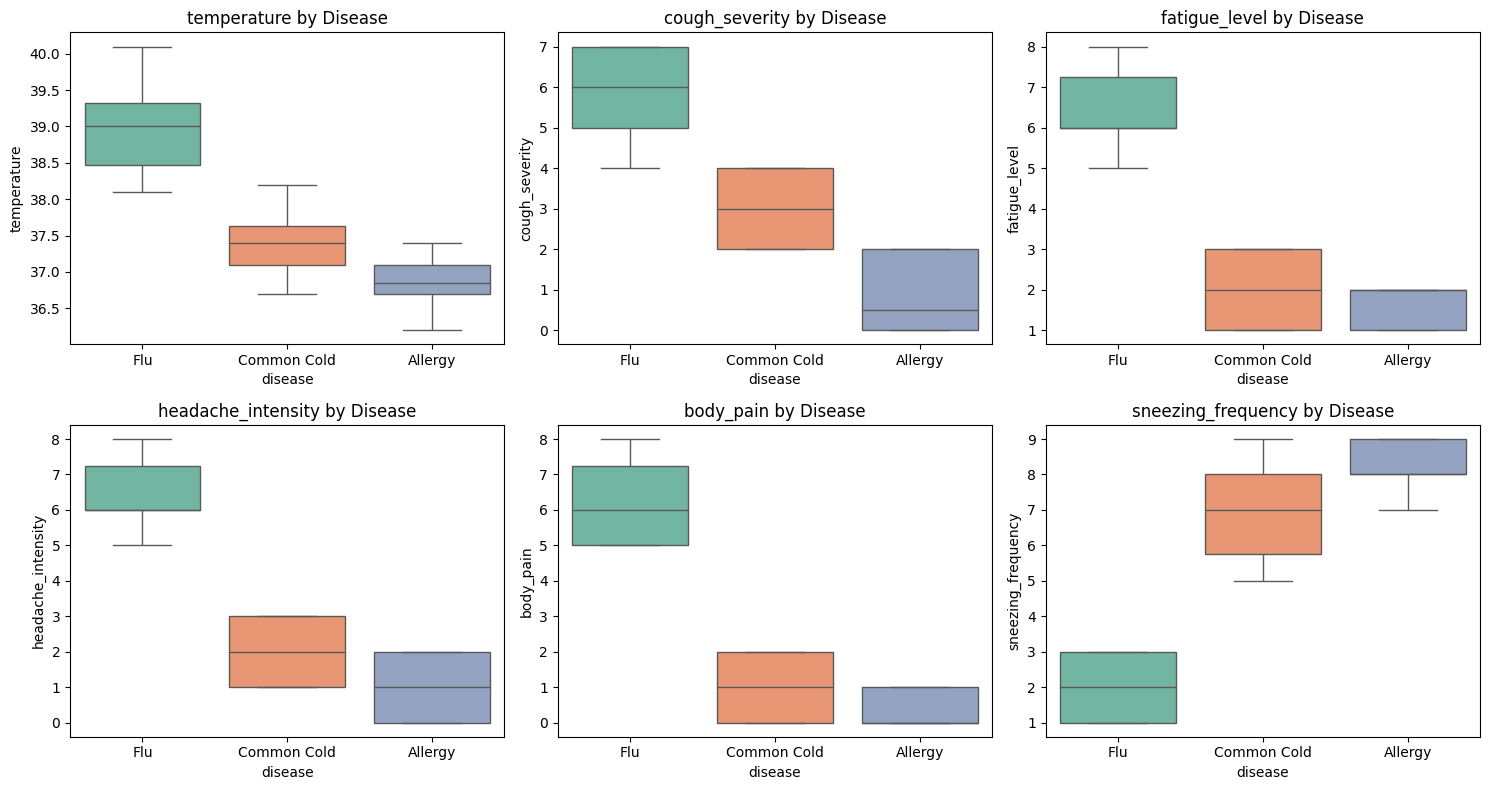

In [25]:
# Distribution of features by disease
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
plot_features = ['temperature', 'cough_severity', 'fatigue_level',
                 'headache_intensity', 'body_pain', 'sneezing_frequency']

for i, feature in enumerate(plot_features):
    row, col = i // 3, i % 3
    sns.boxplot(x='disease', y=feature, data=df, ax=axes[row, col], palette='Set2')
    axes[row, col].set_title(f'{feature} by Disease')

plt.tight_layout()
plt.show()

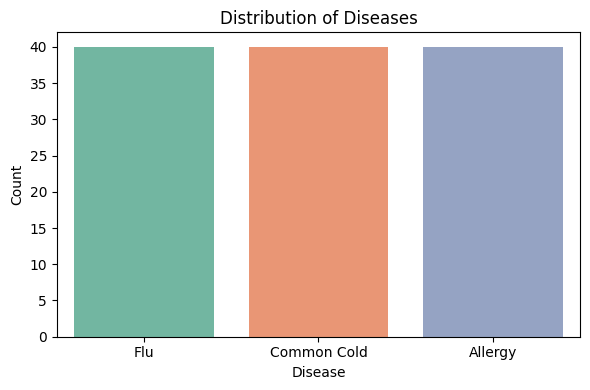

In [26]:
plt.figure(figsize=(6, 4))
sns.countplot(x='disease', data=df, palette='Set2')
plt.title('Distribution of Diseases')
plt.xlabel('Disease')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

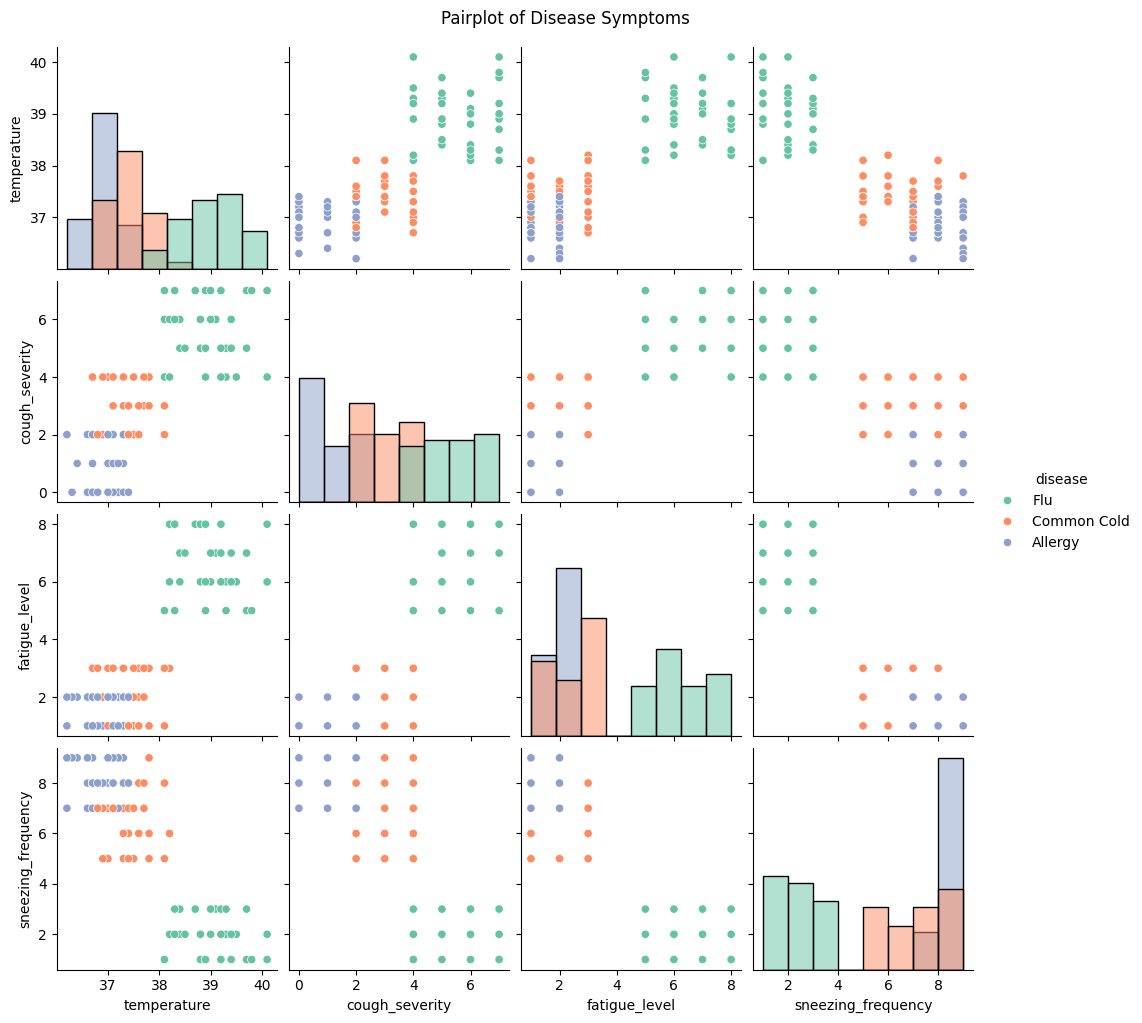

In [27]:
sns.pairplot(df, hue='disease', vars=['temperature', 'cough_severity', 'fatigue_level', 'sneezing_frequency'],
             palette='Set2', diag_kind='hist')
plt.suptitle('Pairplot of Disease Symptoms', y=1.02)
plt.show()

## 5. Data Preprocessing

### 5.1 Train-Test Split

All features in this dataset are already numerical, so no encoding is needed.

In [28]:
feature_cols = ['temperature', 'cough_severity', 'fatigue_level', 'headache_intensity',
                'body_pain', 'sneezing_frequency', 'age']
X = df[feature_cols]
y = df['disease']

print("Features (X) shape:", X.shape)
print("Target (y) shape:", y.shape)
print(f"\nFeatures used: {feature_cols}")

# 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"\nTraining set size: {X_train.shape[0]}")
print(f"Testing set size: {X_test.shape[0]}")

Features (X) shape: (120, 7)
Target (y) shape: (120,)

Features used: ['temperature', 'cough_severity', 'fatigue_level', 'headache_intensity', 'body_pain', 'sneezing_frequency', 'age']

Training set size: 96
Testing set size: 24


### 5.2 Feature Scaling (StandardScaler)

KNN uses **distance** to find neighbors. If features have different scales, the feature with larger values will dominate the distance calculation.

**StandardScaler** transforms each feature to have:
- **Mean = 0**
- **Standard Deviation = 1**

$$z = \frac{x - \mu}{\sigma}$$

**Important:** We fit the scaler on training data only, then transform both train and test sets. This prevents **data leakage** (the model should not "see" test data during training).

In [29]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Before Scaling (training set):")
print(f"  Feature means: {X_train.mean().values.round(2)}")
print(f"  Feature stds:  {X_train.std().values.round(2)}")
print(f"\nAfter Scaling (training set):")
print(f"  Feature means: {X_train_scaled.mean(axis=0).round(2)}")
print(f"  Feature stds:  {X_train_scaled.std(axis=0).round(2)}")

Before Scaling (training set):
  Feature means: [37.85  3.23  3.56  3.29  2.7   5.38 37.91]
  Feature stds:  [ 1.01  2.16  2.34  2.64  2.88  2.95 16.24]

After Scaling (training set):
  Feature means: [ 0.  0. -0.  0.  0.  0. -0.]
  Feature stds:  [1. 1. 1. 1. 1. 1. 1.]


## 6. Build KNN Model

In [30]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)

print(f"KNN Model trained with K = {knn.n_neighbors}")
print(f"Number of training samples: {X_train_scaled.shape[0]}")
print(f"Number of features: {X_train_scaled.shape[1]}")

KNN Model trained with K = 5
Number of training samples: 96
Number of features: 7


## 7. Make Predictions

In [31]:
y_pred = knn.predict(X_test_scaled)

comparison = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_pred,
    'Correct': y_test.values == y_pred
})
print("Actual vs Predicted Disease:")
comparison

Actual vs Predicted Disease:


,Actual,Predicted,Correct
0,Allergy,Allergy,True
1,Allergy,Allergy,True
2,Common Cold,Allergy,False
3,Allergy,Allergy,True
4,Common Cold,Common Cold,True
5,Allergy,Allergy,True
6,Flu,Flu,True
7,Common Cold,Common Cold,True
8,Common Cold,Allergy,False
9,Allergy,Allergy,True


## 8. Confusion Matrix (Multiclass)

For **binary** classification (Day 13), our confusion matrix was **2x2** (TP, TN, FP, FN).

For **multiclass** classification with 3 classes (Diseases), it becomes a **3x3** matrix. Each cell `[i, j]` shows how many samples of class `i` were predicted as class `j`.

- **Diagonal values** = Correct predictions
- **Off-diagonal values** = Misclassifications

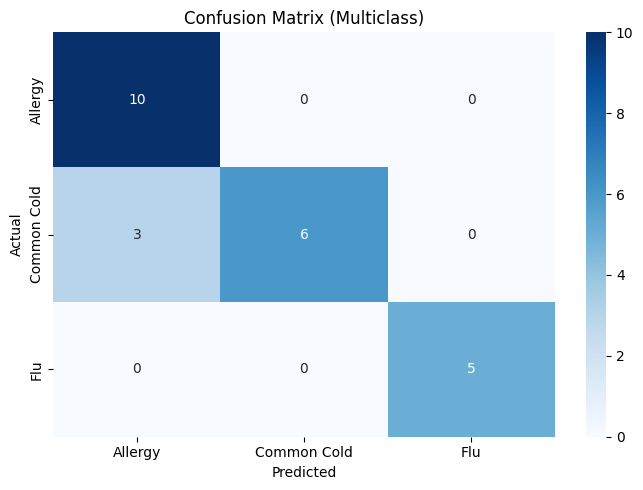


Reading the matrix:
  10 Allergy correctly classified
  3 Common Cold misclassified as Allergy
  6 Common Cold correctly classified
  5 Flu correctly classified


In [32]:
class_names = ['Allergy', 'Common Cold', 'Flu']
cm = confusion_matrix(y_test, y_pred, labels=class_names)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix (Multiclass)')
plt.tight_layout()
plt.show()

print("\nReading the matrix:")
for i, actual in enumerate(class_names):
    for j, predicted in enumerate(class_names):
        count = cm[i][j]
        if count > 0:
            if i == j:
                print(f"  {count} {actual} correctly classified")
            else:
                print(f"  {count} {actual} misclassified as {predicted}")

## 9. Evaluation Metrics for Multiclass Classification

In **binary** classification (Day 13), computing Precision, Recall, and F1 is straightforward since there's only one positive and one negative class.

In **multiclass** classification, we have 3 classes. So we need to decide **how to average** the per-class metrics into a single number. There are 3 common strategies:

| Averaging | How it Works |
|-----------|--------------|
| **Macro** | Calculate metric for each class separately, then take the **simple average** |
| **Micro** | Combine all predictions together and compute one overall score |
| **Weighted** | Calculate metric for each class, but give **more weight to larger classes** |

### 9.1 Accuracy

**Formula:**

$$Accuracy = \frac{\text{Number of Correct Predictions}}{\text{Total Number of Predictions}}$$

**Explanation:**
- Accuracy measures the **proportion of correct predictions** out of all predictions.
- For multiclass, it is simply: how many patients (across all diseases) were classified correctly?
- **Range**: 0 to 1 (or 0% to 100%).
- **Advantage**: Simple and intuitive.
- **Disadvantage**: Can be misleading when one class has many more samples than others.

In [33]:
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")
print(f"\nInterpretation: Our KNN model correctly classifies {accuracy*100:.2f}% of patients.")

Accuracy: 0.8750

Interpretation: Our KNN model correctly classifies 87.50% of patients.


### 9.2 Precision (Multiclass)

**Formula (per class):**

$$Precision_i = \frac{TP_i}{TP_i + FP_i}$$

**Macro Average:**

$$Precision_{macro} = \frac{1}{N} \sum_{i=1}^{N} Precision_i$$

**Explanation:**
- For each disease, precision asks: "Of all patients predicted as this disease, how many actually have it?"
- **Macro** averaging treats all diseases equally.
- **Weighted** averaging gives more importance to diseases with more samples.
- **Range**: 0 to 1.

In [34]:
precision_macro = precision_score(y_test, y_pred, average='macro')
precision_weighted = precision_score(y_test, y_pred, average='weighted')

print(f"Precision (Macro):    {precision_macro:.4f}")
print(f"Precision (Weighted): {precision_weighted:.4f}")
print(f"\nMacro: each disease contributes equally to the average.")
print(f"Weighted: diseases with more samples contribute more.")

Precision (Macro):    0.9231
Precision (Weighted): 0.9038

Macro: each disease contributes equally to the average.
Weighted: diseases with more samples contribute more.


### 9.3 Recall (Multiclass)

**Formula (per class):**

$$Recall_i = \frac{TP_i}{TP_i + FN_i}$$

**Macro Average:**

$$Recall_{macro} = \frac{1}{N} \sum_{i=1}^{N} Recall_i$$

**Explanation:**
- For each disease, recall asks: "Of all actual patients with this disease, how many did the model correctly identify?"
- Important when **missing a disease is costly** (e.g., failing to identify Flu in a patient).
- **Range**: 0 to 1.

In [35]:
recall_macro = recall_score(y_test, y_pred, average='macro')
recall_weighted = recall_score(y_test, y_pred, average='weighted')

print(f"Recall (Macro):    {recall_macro:.4f}")
print(f"Recall (Weighted): {recall_weighted:.4f}")
print(f"\nInterpretation: Our model correctly identifies {recall_macro*100:.2f}% of patients on average across all diseases.")

Recall (Macro):    0.8889
Recall (Weighted): 0.8750

Interpretation: Our model correctly identifies 88.89% of patients on average across all diseases.


### 9.4 F1 Score (Multiclass)

**Formula (per class):**

$$F1_i = 2 \times \frac{Precision_i \times Recall_i}{Precision_i + Recall_i}$$

**Macro Average:**

$$F1_{macro} = \frac{1}{N} \sum_{i=1}^{N} F1_i$$

**Explanation:**
- F1 Score is the **harmonic mean** of Precision and Recall for each class.
- Provides a **single metric that balances** both precision and recall.
- **Range**: 0 to 1. F1 = 1 means perfect precision AND recall for that disease.
- **Macro F1** is the most commonly reported metric for multiclass classification.

In [36]:
f1_macro = f1_score(y_test, y_pred, average='macro')
f1_weighted = f1_score(y_test, y_pred, average='weighted')

print(f"F1 Score (Macro):    {f1_macro:.4f}")
print(f"F1 Score (Weighted): {f1_weighted:.4f}")
print(f"\nInterpretation: The macro F1 of {f1_macro:.4f} shows our model balances precision and recall well across all 3 diseases.")

F1 Score (Macro):    0.8899
F1 Score (Weighted): 0.8707

Interpretation: The macro F1 of 0.8899 shows our model balances precision and recall well across all 3 diseases.


## 10. Classification Report

In [37]:
print("\nComplete Classification Report:")
print("=" * 55)
print(classification_report(y_test, y_pred))


Complete Classification Report:
              precision    recall  f1-score   support

     Allergy       0.77      1.00      0.87        10
 Common Cold       1.00      0.67      0.80         9
         Flu       1.00      1.00      1.00         5

    accuracy                           0.88        24
   macro avg       0.92      0.89      0.89        24
weighted avg       0.90      0.88      0.87        24



## 11. Summary of All Evaluation Metrics

In [38]:
metrics_summary = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision (Macro)', 'Recall (Macro)', 'F1 Score (Macro)'],
    'Value': [f'{accuracy:.4f}', f'{precision_macro:.4f}', f'{recall_macro:.4f}', f'{f1_macro:.4f}'],
    'Question Answered': [
        'How often is the model correct overall?',
        'When it predicts a disease, how often is it right?',
        'How many actual patients of each disease does it find?',
        'What is the balance between precision and recall?'
    ],
    'Best Value': ['1', '1', '1', '1']
})

print("=" * 75)
print("           KNN MODEL EVALUATION METRICS SUMMARY")
print("=" * 75)
print(metrics_summary.to_string(index=False))
print("=" * 75)

           KNN MODEL EVALUATION METRICS SUMMARY
           Metric  Value                                      Question Answered Best Value
         Accuracy 0.8750                How often is the model correct overall?          1
Precision (Macro) 0.9231     When it predicts a disease, how often is it right?          1
   Recall (Macro) 0.8889 How many actual patients of each disease does it find?          1
 F1 Score (Macro) 0.8899      What is the balance between precision and recall?          1


## 12. Visualizing Model Performance

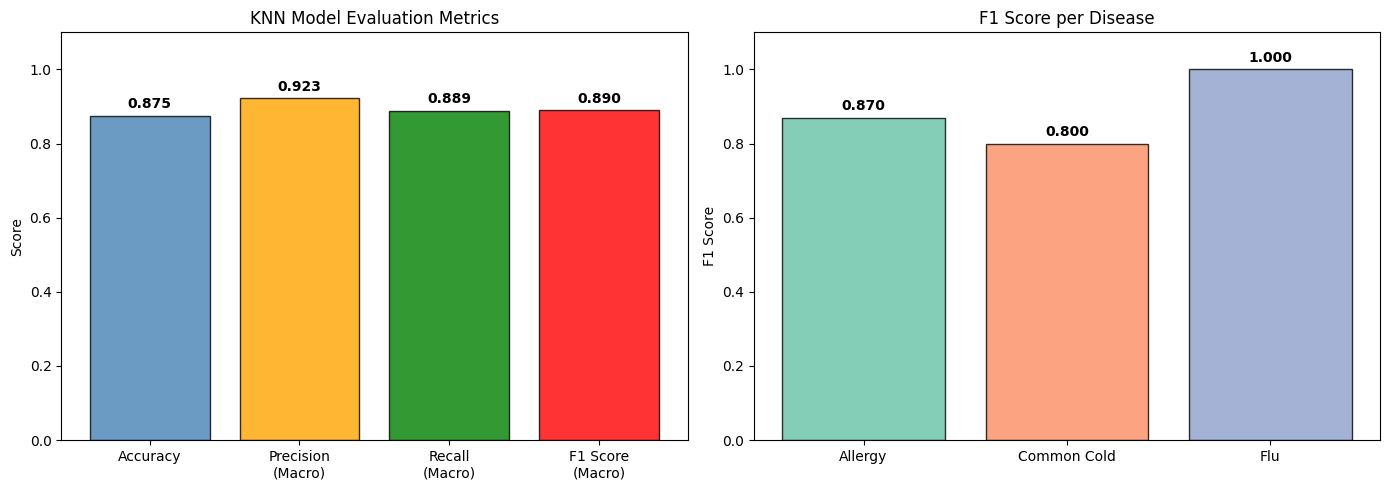

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

metrics_names = ['Accuracy', 'Precision\n(Macro)', 'Recall\n(Macro)', 'F1 Score\n(Macro)']
metrics_values = [accuracy, precision_macro, recall_macro, f1_macro]
colors = ['steelblue', 'orange', 'green', 'red']

axes[0].bar(metrics_names, metrics_values, color=colors, edgecolor='black', alpha=0.8)
axes[0].set_ylim(0, 1.1)
axes[0].set_ylabel('Score')
axes[0].set_title('KNN Model Evaluation Metrics')
for i, v in enumerate(metrics_values):
    axes[0].text(i, v + 0.02, f'{v:.3f}', ha='center', fontweight='bold')

f1_per_class = f1_score(y_test, y_pred, average=None, labels=class_names)
class_colors = ['#66c2a5', '#fc8d62', '#8da0cb']

axes[1].bar(class_names, f1_per_class, color=class_colors, edgecolor='black', alpha=0.8)
axes[1].set_ylim(0, 1.1)
axes[1].set_ylabel('F1 Score')
axes[1].set_title('F1 Score per Disease')
for i, v in enumerate(f1_per_class):
    axes[1].text(i, v + 0.02, f'{v:.3f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

## 13. Choosing the Best K

The choice of **K** (number of neighbors) significantly affects KNN performance:
- **Small K** (e.g., K=1): Model memorizes every point, sensitive to noise (**overfitting**)
- **Large K** (e.g., K=50): Model becomes too general, ignores local patterns (**underfitting**)

Let's try different values of K and see which gives the best accuracy.

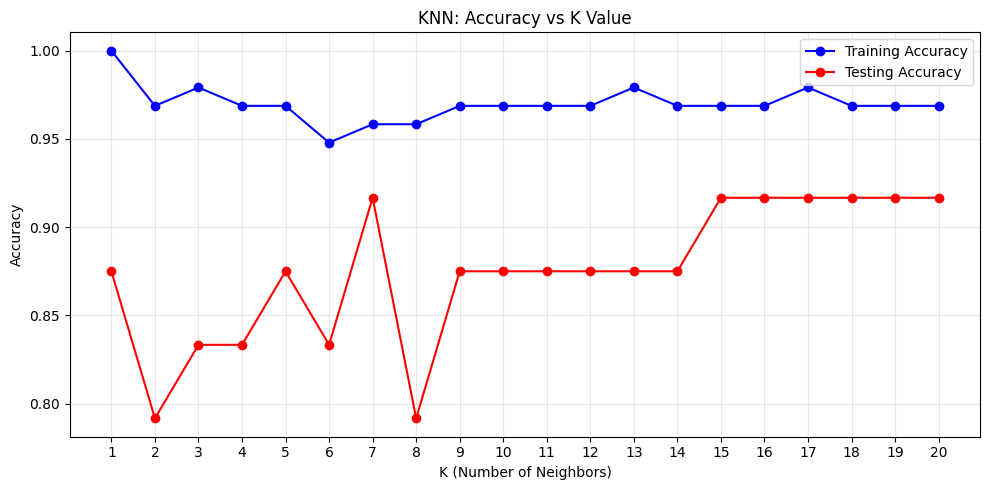


Best K = 7 with Test Accuracy = 0.9167


In [40]:
k_range = range(1, 21)
train_scores = []
test_scores = []

for k in k_range:
    knn_temp = KNeighborsClassifier(n_neighbors=k)
    knn_temp.fit(X_train_scaled, y_train)
    train_scores.append(knn_temp.score(X_train_scaled, y_train))
    test_scores.append(knn_temp.score(X_test_scaled, y_test))

plt.figure(figsize=(10, 5))
plt.plot(k_range, train_scores, 'o-', label='Training Accuracy', color='blue')
plt.plot(k_range, test_scores, 'o-', label='Testing Accuracy', color='red')
plt.xlabel('K (Number of Neighbors)')
plt.ylabel('Accuracy')
plt.title('KNN: Accuracy vs K Value')
plt.xticks(k_range)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

best_k = list(k_range)[np.argmax(test_scores)]
print(f"\nBest K = {best_k} with Test Accuracy = {max(test_scores):.4f}")

## 14. Decision Boundary Visualization

To visualize how KNN classifies data, we use only **2 features** so we can plot in 2D. The colored regions show which disease KNN would predict for any point in that area.

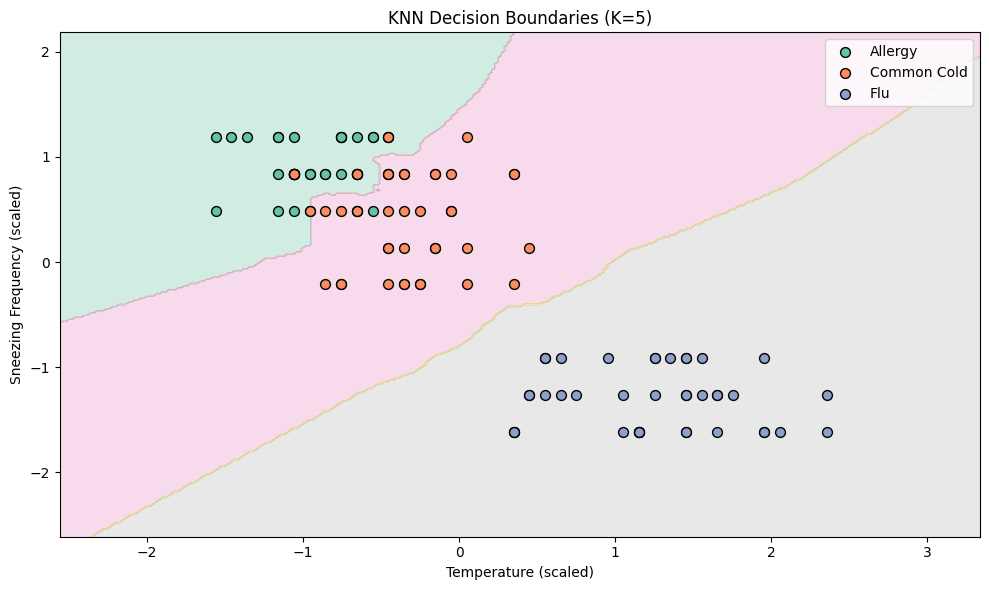

In [41]:
X_2d = df[['temperature', 'sneezing_frequency']].values

le_disease = LabelEncoder()
y_2d = le_disease.fit_transform(df['disease'])

scaler_2d = StandardScaler()
X_2d_scaled = scaler_2d.fit_transform(X_2d)

knn_2d = KNeighborsClassifier(n_neighbors=5)
knn_2d.fit(X_2d_scaled, y_2d)

h = 0.02
x_min, x_max = X_2d_scaled[:, 0].min() - 1, X_2d_scaled[:, 0].max() + 1
y_min, y_max = X_2d_scaled[:, 1].min() - 1, X_2d_scaled[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

Z = knn_2d.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(10, 6))
plt.contourf(xx, yy, Z, alpha=0.3, cmap='Set2')

disease_list = le_disease.classes_
colors = ['#66c2a5', '#fc8d62', '#8da0cb']
for i, (name, color) in enumerate(zip(disease_list, colors)):
    mask = y_2d == i
    plt.scatter(X_2d_scaled[mask, 0], X_2d_scaled[mask, 1],
                c=color, label=name, edgecolors='black', s=50)

plt.xlabel('Temperature (scaled)')
plt.ylabel('Sneezing Frequency (scaled)')
plt.title('KNN Decision Boundaries (K=5)')
plt.legend()
plt.tight_layout()
plt.show()

## 15. KNN vs Logistic Regression

| Feature | K-Nearest Neighbors (KNN) | Logistic Regression |
|---------|---------------------------|--------------------|
| **How it learns** | Memorizes all training data | Learns a formula from data |
| **Training time** | No training needed | Needs to train on data |
| **Decision boundary** | Flexible, curved | Straight line |
| **Key setting** | K (number of neighbors) | Regularization (C) |
| **Feature scaling** | Required | Recommended but not required |
| **Explainability** | Hard to explain why | Easy (feature weights show importance) |
| **Prediction speed** | Slow (checks all training points) | Fast (just applies a formula) |
| **Multiclass** | Works directly with voting | Needs extra setup |
| **Best for** | Small datasets, complex patterns | Large datasets, simple patterns |

## Conclusion

- We built a **K-Nearest Neighbors** model to classify patients into 3 diseases (Flu, Common Cold, Allergy) using the Disease Symptoms dataset.
- **Feature scaling** is essential for KNN because it uses distance to find neighbors.
- The **confusion matrix** for multiclass is NxN (3x3 for 3 diseases) instead of 2x2.
- For multiclass metrics, we use **averaging strategies** (macro, micro, weighted) to compute a single Precision, Recall, and F1 Score.
- We found the **optimal K** by testing multiple values and plotting accuracy.
- **Decision boundary visualization** shows how KNN creates flexible, curved boundaries.
- KNN is simple and powerful for small datasets, but becomes slow for large ones since it must compute distances to all training points.